# Multimodal pattern-aware training — executed results

A CPU simulation comparing **global gates**, **per-record quality gates**, and **five-token self-attention** for retrieval. All records and input vectors are synthetic. This notebook uses the reusable implementation in `src/pattern_aware`.

The experiment is deliberately small: 48 records in 12 patterns. Perfect scores here demonstrate the pipeline; they do not establish real-world accuracy or a superior architecture.

Install the repository requirements and select that environment's Python kernel before running all cells. See the README for commands.

This output was regenerated from the public package. Run details appear below.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
from pattern_aware import run_experiment

ROOT = Path.cwd()
if not (ROOT / "configs/demo.json").exists():
    ROOT = ROOT.parent
assert (ROOT / "configs/demo.json").exists(), "Start Jupyter from the repository root or notebooks directory."
config = json.loads((ROOT / "configs/demo.json").read_text())
display(config)

{'training': {'seed': 42,
  'epochs': 18,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'temperature': 0.07,
  'patterns_per_batch': 3,
  'members_per_pattern': 2,
  'patience': 5,
  'minimum_delta': 1e-05},
 'variants': ['v1', 'v11', 'v2'],
 'k_values': [1, 5, 10, 30],
 'save_checkpoints': False,
 'plots': True,
 'cpu_threads': 1}

## 1. Generate data, train, and select checkpoints

Each pattern belongs to exactly one split. A shared latent produces five frozen modality spaces. Content masks represent unavailable modalities; source masks distinguish absent structured sources from present sources with no usable content. One test record has every modality missing.

The sampler uses up to three patterns per batch, with two distinct records per pattern. All anchors have positives and cross-pattern negatives. Each variant trains with a masked multi-positive supervised contrastive loss. Checkpoint selection uses validation pattern-macro NDCG@30 only; test data is evaluated after selection.

In [2]:
result = run_experiment(config=config, output=ROOT / "artifacts/notebook")
summary = result.summary
display(pd.DataFrame(summary["splits"]).T)
display(summary["environment"])

,patterns,records,eligible_records
train,7,28,28
validation,3,12,12
test,2,8,7


{'python': '3.12.14',
 'numpy': '2.2.4',
 'pandas': '2.2.3',
 'torch': '2.6.0+cpu',
 'device': 'cpu',
 'cpu_threads': 1,
 'deterministic_algorithms': True}

## 2. Compare fusion variants

All variants adapt five modalities to 128-dimensional tokens and project to a normalized 256-dimensional embedding. V1 uses learned global gates. V1.1 conditions its gates on one synthetic quality scalar per modality. V2 adds four-head token self-attention **before** applying the quality gates.

The table includes the mask-only control, which uses seven availability bits and no semantic vectors. This is a diagnostic, not a calibrated random baseline.

In [3]:
rows = []
for key, model in summary["models"].items():
    rows.append({
        "model": model["name"], "parameters": model["parameter_count"],
        "selected_epoch": model["selected_epoch"], "epochs_run": model["epochs_executed"],
        "validation_NDCG@30": model["validation"]["pattern_macro"]["NDCG@30"],
        "test_NDCG@30": model["test"]["pattern_macro"]["NDCG@30"],
    })
display(pd.DataFrame(rows))
display(pd.DataFrame({split: summary["mask_only"][split]["pattern_macro"]
                      for split in ("validation", "test")}))

,model,parameters,selected_epoch,epochs_run,validation_NDCG@30,test_NDCG@30
0,V1 global gates,1025413,9,14,1.0,1.0
1,V1.1 per-record quality gates,1025418,9,14,1.0,1.0
2,V2 self-attention,1158538,2,7,1.0,1.0


,validation,test
RECALL@1,0.027778,0.250000
NDCG@1,0.083333,0.666667
AP@1,0.083333,0.666667
RECALL@5,0.361111,0.916667
NDCG@5,0.263274,0.757349
AP@5,0.142130,0.662500
RECALL@10,0.916667,1.000000
NDCG@10,0.509369,0.793750
AP@10,0.304056,0.690278
RECALL@30,1.000000,1.000000


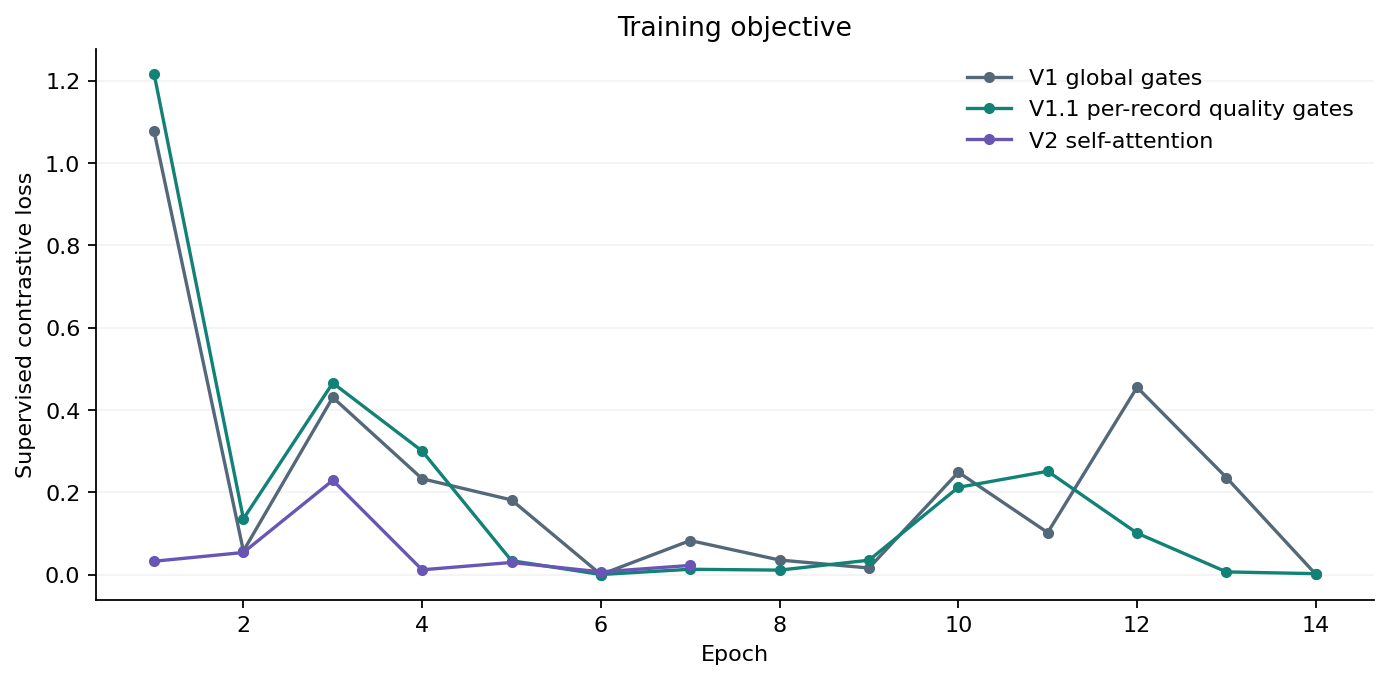

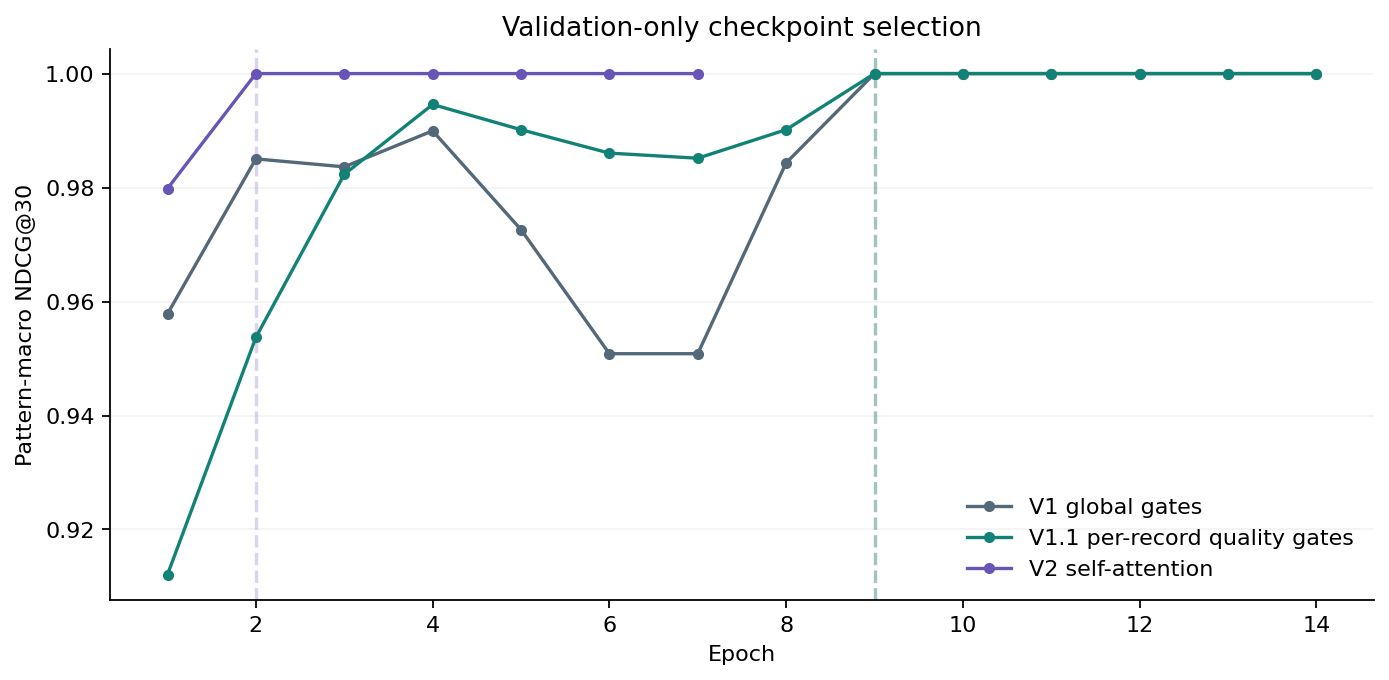

In [4]:
for filename in ("training.png", "validation_selection.png"):
    display(Image(filename=str(result.output_dir / "figures" / filename)))

## 3. Inspect reliability gates and attention

Missing modalities have exactly zero gate weight. V1 has one gate value per available modality across all records. V1.1 and V2 can vary by record, but their learned quality slope may be negative. Gates are not calibrated reliability probabilities.

Because V2 gates follow attention, a low-quality token may already have influenced another token. Attention weights describe model computation and are not causal feature importance.

,model,record_id,pattern_id,modality,available,quality,gate
0,v1,record_00029,P-008,location,True,0.578882,0.503246
1,v1,record_00029,P-008,time,True,0.455518,0.503343
2,v1,record_00029,P-008,narrative,True,0.353130,0.502250
3,v1,record_00029,P-008,suspect,True,0.596044,0.501350
4,v1,record_00029,P-008,weapon,False,0.000000,0.000000
5,v1,record_00030,P-008,location,True,0.849891,0.503246
6,v1,record_00030,P-008,time,True,0.611052,0.503343
7,v1,record_00030,P-008,narrative,True,0.677132,0.502250
8,v1,record_00030,P-008,suspect,True,0.588194,0.501350
9,v1,record_00030,P-008,weapon,False,0.000000,0.000000


,model,modality,quality_weight,bias
0,v1,location,NaN,0.012985
1,v1,time,NaN,0.013374
2,v1,narrative,NaN,0.009002
3,v1,suspect,NaN,0.005399
4,v1,weapon,NaN,0.016229
5,v11,location,0.299525,-0.195477
6,v11,time,-0.891498,0.299714
7,v11,narrative,0.389527,-0.985498
8,v11,suspect,-0.371083,0.335967
9,v11,weapon,0.658185,-0.631640


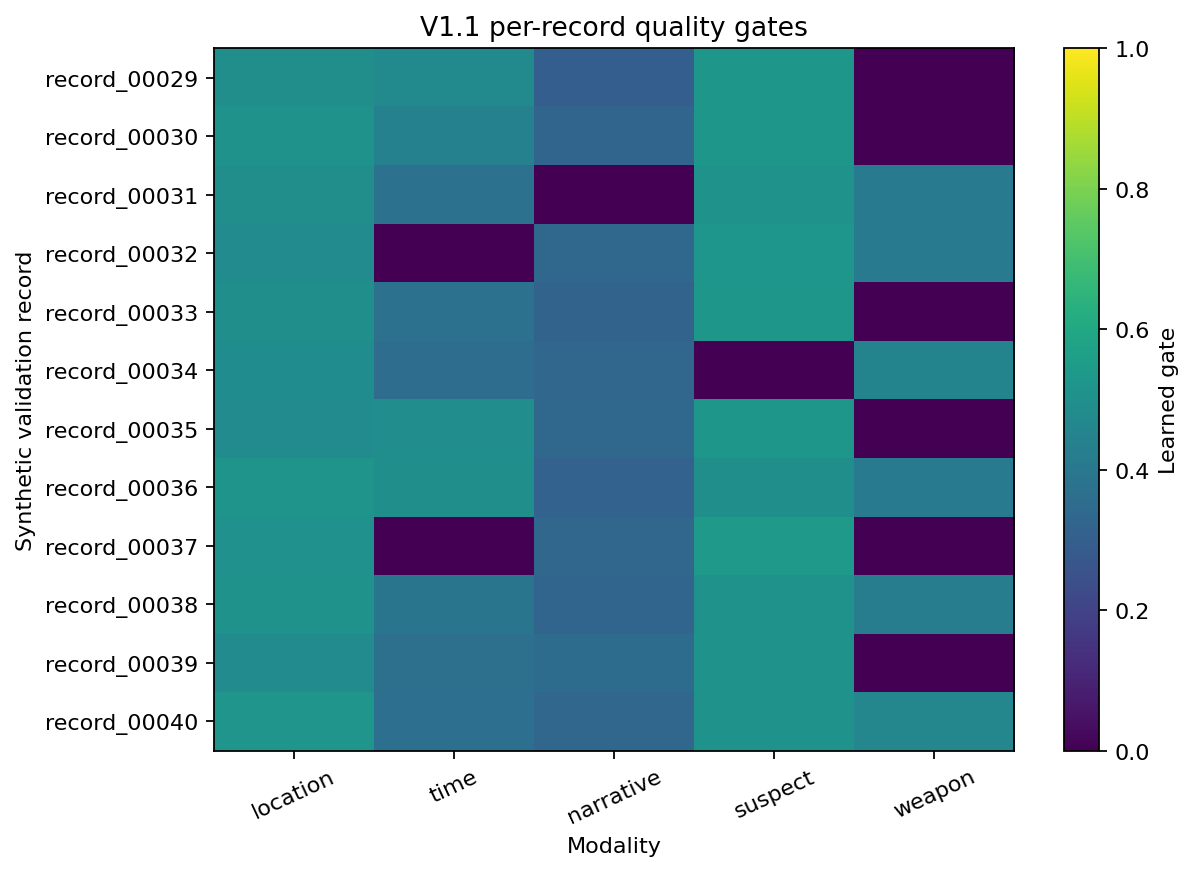

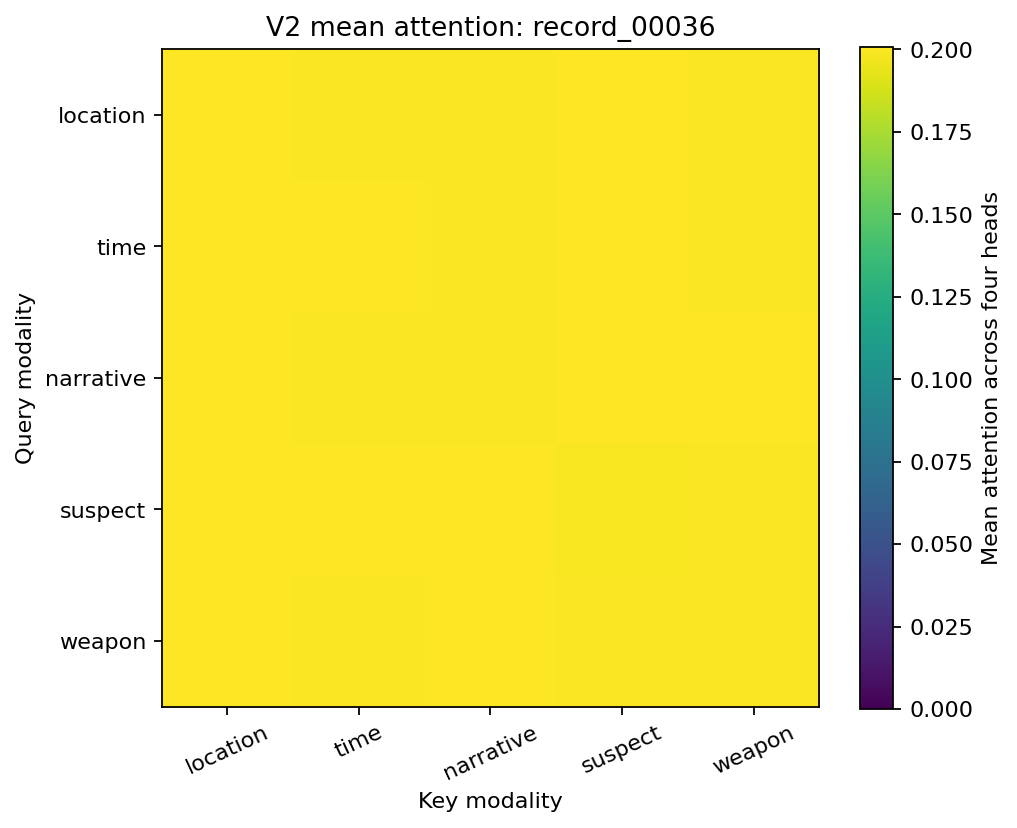

In [5]:
display(result.gates.head(15))
display(pd.read_csv(result.output_dir / "gate_parameters.csv"))
for filename in ("gates_v11.png", "attention_v2.png"):
    display(Image(filename=str(result.output_dir / "figures" / filename)))

## 4. Inspect a ranked gallery

Retrieval compares each eligible query with its own split's eligible gallery, excludes the query itself, and treats same-pattern candidates as relevant. Ties use synthetic record IDs. Pattern-macro scores first average within each pattern, then give each pattern equal weight.

In [6]:
display(result.rankings.head(12))
display(summary["models"]["v2"]["test"])

,model,split,query_record_id,query_pattern_id,rank,candidate_record_id,candidate_pattern_id,cosine_similarity,relevant_same_pattern
0,v1,validation,record_00029,P-008,1,record_00030,P-008,0.986424,True
1,v1,validation,record_00029,P-008,2,record_00032,P-008,0.965681,True
2,v1,validation,record_00029,P-008,3,record_00031,P-008,0.934973,True
3,v1,validation,record_00029,P-008,4,record_00039,P-010,0.288680,False
4,v1,validation,record_00029,P-008,5,record_00038,P-010,0.184655,False
5,v1,validation,record_00029,P-008,6,record_00040,P-010,0.154585,False
6,v1,validation,record_00029,P-008,7,record_00037,P-010,0.051140,False
7,v1,validation,record_00029,P-008,8,record_00036,P-009,-0.004013,False
8,v11,validation,record_00029,P-008,1,record_00030,P-008,0.991946,True
9,v11,validation,record_00029,P-008,2,record_00032,P-008,0.980149,True


{'available_gallery_records': 7,
 'eligible_query_records': 7,
 'eligible_patterns': 2,
 'self_match_removed': True,
 'requested_k_values': [1, 5, 10, 30],
 'effective_k_values': {'1': 1, '5': 5, '10': 6, '30': 6},
 'ap_convention': 'truncated_denominator_min_relevant_k',
 'pattern_macro': {'RECALL@1': 0.41666666666666663,
  'NDCG@1': 1.0,
  'AP@1': 1.0,
  'RECALL@5': 1.0,
  'NDCG@5': 1.0,
  'AP@5': 1.0,
  'RECALL@10': 1.0,
  'NDCG@10': 1.0,
  'AP@10': 1.0,
  'RECALL@30': 1.0,
  'NDCG@30': 1.0,
  'AP@30': 1.0},
 'query_micro': {'RECALL@1': 0.4047619047619047,
  'NDCG@1': 1.0,
  'AP@1': 1.0,
  'RECALL@5': 1.0,
  'NDCG@5': 1.0,
  'AP@5': 1.0,
  'RECALL@10': 1.0,
  'NDCG@10': 1.0,
  'AP@10': 1.0,
  'RECALL@30': 1.0,
  'NDCG@30': 1.0,
  'AP@30': 1.0}}

## 5. Interpret the limits

- With only 11 validation candidates and six test candidates per query, K=30 covers the entire gallery. Recall@30 is necessarily 1.0; NDCG still reflects ordering.
- The synthetic task saturates for all three trained models. It does not establish that attention or quality gating improves performance.
- The source notebooks use fixed K=2, not adaptive K selection. Every epoch samples K members per pattern and need not see every record.
- Quality scores are constructed to correlate with simulated noise. Real quality signals would require separate validation.
- The mask-only control can be affected by tied similarities and pattern-ordered record IDs.
- Larger galleries, multiple seeds, untrained baselines, and missingness/noise sweeps are needed for stronger conclusions.

See `docs/methodology.md`, `docs/results.md`, and `docs/reproducibility.md` for metric definitions and reproduction details.